# Histogram filter

Assume we have a robot that can be in one of five blocks. With no other info we calculate the probability of the robot being in each such and plot a histogram of the probabilities:

In [1]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, signal

<BarContainer object of 5 artists>

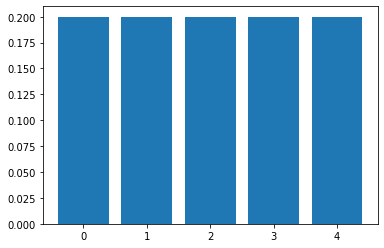

In [9]:
no_of_blocks = 5
prb = 1/5

# Initialize the probability distribution.
# Since we have no prior information, we assign a uniform probability to each block.
# Sum(p) must equal 1.
p = [prb, prb, prb, prb, prb]

plt.bar(range(no_of_blocks), p)

Now we say that each block is either red or green and that our robot can sense that colour. We multiply all the correct sensings with 0.6 and the incorrect with 0.2. These values are arbitrary and just represent that the robot has a higher probability to be at a red block if that is what is measured.

In the following we define the world and make a function that calculates the new probabilities by using the measurement. We then try it out with a measurement of 'red'.

Notice that we divide each probability with the sum of all probabilities in order to get something that adds up to one.

[0.11111111 0.33333333 0.33333333 0.11111111 0.11111111]


<BarContainer object of 5 artists>

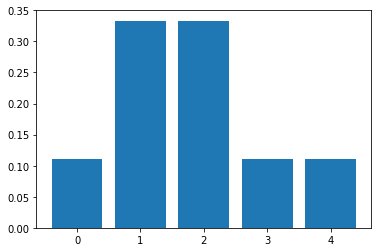

In [12]:
no_of_blocks = 5
prb = 1/5
p = [prb, prb, prb, prb, prb]

# Define the map of the world (colors of the grid cells)
world = ['green', 'red', 'red', 'green', 'green']
z = 'red' # The actual measurement received from the sensor

# Sensor model probabilities
# pHit: Probability of measuring the correct color given we are at that color. P(z=red | world=red)
# pMiss: Probability of measuring the wrong color. P(z=red | world=green)
pHit = 0.6
pMiss = 0.2

def sense(p,z):
    q = []
    # Loop through every possible location (grid cell) in the world
    for i in range(len(world)):
        # Check if the measurement 'z' matches the color of the current cell 'world[i]'
        hit = (z == world[i]) # Returns 1 (True) or 0 (False)
        
        # Bayesian update (non-normalized): Posterior = Prior * Likelihood
        # p[i] is the Prior. 
        # (hit * pHit + (1- hit) * pMiss) is the Likelihood P(z|x).
        q.append(p[i]*(hit * pHit + (1- hit) * pMiss))
        
    # Normalization:
    # Divide by the sum of all elements so the total probability sums to 1 again.
    # This accounts for the Evidence term P(z) in Bayes' rule.
    q = np.array(q)/sum(q) 
    return q


q = sense(p,z)
print(q)

plt.bar(range(no_of_blocks), q)

Next we make a function that moves the robot. This is easily done using the numpy roll method:

<BarContainer object of 5 artists>

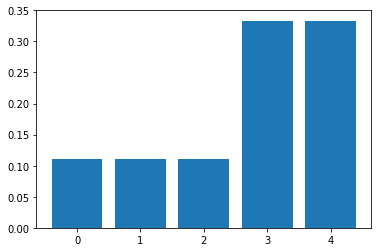

In [13]:
def move(p, U):
    # np.roll shifts the elements of the array.
    # A positive U shifts right, effectively simulating movement in a cyclic world.
    # (i.e., if the robot moves off the right edge, it appears on the left).
    q=np.roll(p,U)
    return q

# Move the robot 2 steps to the right
q = move(q, 2)
plt.bar(range(no_of_blocks), q)

Every time we move there is some uncertainty to the movement, due to measurement uncertainties, etc. We therefore add some uncertainty to the movement. We do this by convolving the uncertainty with the probabilites. We use a scipy filter to do this:

<BarContainer object of 5 artists>

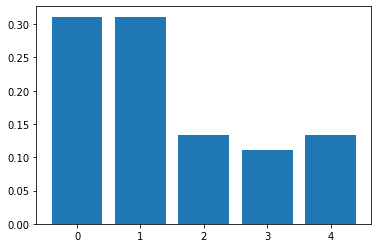

In [14]:
# Define the motion kernel (uncertainty profile).
# This represents: 
# 10% chance it undershot (moved 1 less step), 
# 80% chance it moved exactly U steps,
# 10% chance it overshot (moved 1 extra step).
move_uncertainty=[0.1 , 0.8, 0.1]

def move(p, U, move_uncertainty):
    # First, apply the deterministic shift (ideal movement)
    q=np.roll(p,U)
    
    # Apply convolution to spread the probability distribution according to the uncertainty.
    # This blurs the distribution, representing the loss of information due to noisy motion.
    # mode='wrap' handles the cyclic boundary conditions.
    q=ndimage.convolve1d(q,move_uncertainty,mode='wrap')
    return q

q = move(q, 2, move_uncertainty)
plt.bar(range(no_of_blocks), q)

Now let's see what happens if we move the robot a thousand times without sensing anything:

<BarContainer object of 5 artists>

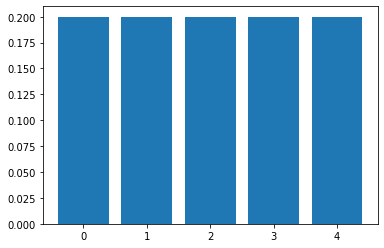

In [15]:
for i in range(1000):
    # Repeatedly moving without sensing causes the probability to spread out uniformly.
    # This is the "Kidnapped Robot Problem" concept; if you close your eyes and keep moving,
    # eventually you have no idea where you are.
    q = move(q, 2, move_uncertainty)
    
plt.bar(range(no_of_blocks), q)

Let's try both sensing and moving. We write the full code:

C:\Users\peisz\AppData\Local\Temp\ipykernel_7720\3069696318.py:25: DeprecationWarning: Please import `convolve1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  q=ndimage.filters.convolve1d(q,move_uncertainty,mode='wrap')


<BarContainer object of 5 artists>

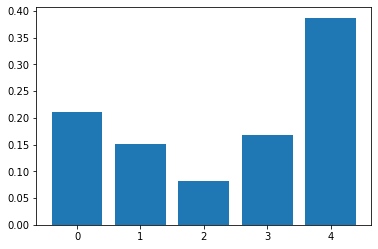

In [16]:
# We define the world, uncertainties, etc. as before.
no_of_blocks = 5
prb = 1/5
p = [prb, prb, prb, prb, prb]
world = ['green', 'red', 'red', 'green', 'green']
measurements=['red','green']
phit=0.6
pmiss=0.2
movements =[1, 1]
move_uncertainty=[0.1 , 0.8, 0.1]

def sense(p, Z):
    q=[]
    for i in range(len(p)):
        hit = (Z == world[i])
        q.append(p[i]*(hit * phit + (1- hit) * pmiss))

    q = np.array(q)/sum(q)
    return q

def move(p, U, move_uncertainty):
    q=np.roll(p,U)
    # Note: ndimage.filters is the old location for convolve1d, but it still works.
    # Modern usage is ndimage.convolve1d directly.
    q=ndimage.filters.convolve1d(q,move_uncertainty,mode='wrap')
    return q

# We make a loop where we measure and move (Recursive Bayes Filter loop)
for i in range(len(movements)):
    # 1. Measurement Update: Sharpen the distribution based on sensor data
    p=sense(p,measurements[i])
    
    # 2. Motion Update: Shift and Blur the distribution based on movement
    p = move(p, movements[i], move_uncertainty)
    
plt.bar(range(no_of_blocks),p)

# Exercise 1
We will now extent the histogram plot to work in 2D. You are given the world map and the move function below. We can now move up, down, left and right in the world. We can plot the map with the probabilities by using plt.imshow.
Insert a sense function that will work in 2D, and loop through the measurements and movements, while showing the probabilities using plt.imshow. You will also need to insert a 2D version of the move_uncertainty.

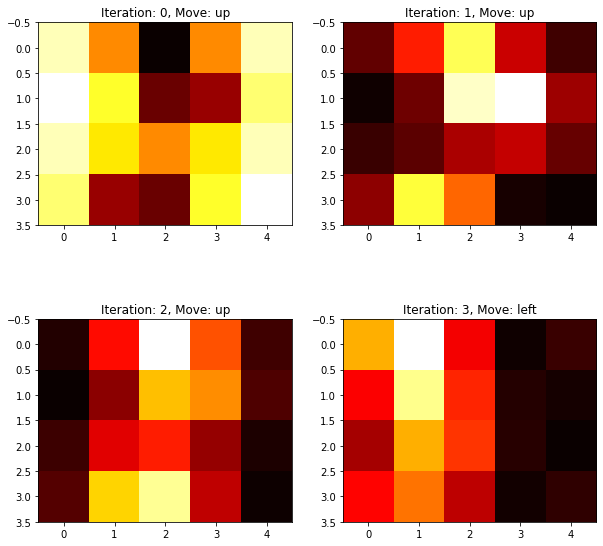

In [19]:
no_of_blocks = 20
prb = 1/20

# The initial probabilities (4x5 grid)
p=[[prb, prb, prb, prb, prb],
   [prb, prb, prb, prb, prb],
   [prb, prb, prb, prb, prb],
   [prb, prb, prb, prb, prb]]

# The world map (4x5 grid)
world = [['red', 'green', 'green', 'red', 'red'],
         ['red', 'red', 'green', 'red', 'red'],
         ['red', 'red', 'green', 'green', 'red'],
         ['red', 'red', 'red', 'red', 'red']]

measurements=['red','green', 'green', 'green']
phit=0.6
pmiss=0.2
movements =['up', 'up', 'up', 'left']

# Define move_uncertainty for 2D.
# This is a 3x3 kernel. The center (0.4) is the probability of landing exactly on target.
# Neighbors represent the probability of drifting into adjacent cells.
move_uncertainty = [[0.05, 0.1, 0.05],
                    [0.1, 0.4, 0.1],
                    [0.05, 0.1, 0.05]]

def sense(p, z):
    q = []
    # Iterate over rows
    for i in range(len(world)):
        row = []
        # Iterate over columns
        for j in range(len(world[0])):
            # Check for match between measurement and world map at (i, j)
            hit = (z == world[i][j])
            
            # Apply Bayes update: Prior * Likelihood
            # p[i][j] is the probability of being in cell (i, j) before sensing.
            row.append(p[i][j] * (hit * phit + (1 - hit) * pmiss))
        q.append(row)
        
    # Normalize the entire 2D grid so the sum of all probabilities equals 1.
    q = np.array(q) / np.sum(q)
    return q
    
def move(p, u, move_uncertainty):
    # Shift the grid based on the move command using np.roll.
    # axis=0 is vertical (rows), axis=1 is horizontal (cols).
    # Note: The sign of the roll depends on the array indexing logic (row 0 is top).
    if u == 'up':
        q = np.roll(p, -1, axis=0) # Shift rows up (index decreases)
    elif u== 'down':
        q = np.roll(p, 1, axis=0)
    elif u == 'right':
        q = np.roll(p, 1, axis=1)
    elif u == 'left':
        q = np.roll(p, -1, axis=1) # Shift cols left
        
    # Apply 2D convolution to handle the uncertainty.
    # boundary='wrap' ensures the robot wraps around the world edges (toroidal world).
    # mode='same' ensures the output grid is the same size as the input.
    q = signal.convolve2d(q, move_uncertainty, boundary='wrap', mode='same')
    return q

# Loop through the measurements and movements
plt.figure(figsize=(10, 10))
for i in range(len(movements)):
    # 1. Sense
    p = sense(p, measurements[i])
    # 2. Move
    p = move(p, movements[i], move_uncertainty)
    
    # Visualize the probability grid
    plt.subplot(int(np.sqrt(len(movements))), int(np.sqrt(len(movements))), i + 1)
    plt.imshow(p, cmap='hot') # Used 'hot' colormap for better visibility of high probability spots
    plt.title(f'Iteration: {i}, Move: {movements[i]}')